# EEG Preprocessing (EDF loading, referencing, filtering, clipping)


In [1]:
# ============================================================
# CELL 1: Imports and environment setup
# ============================================================
# Standard libraries
import os
import glob

# Data handling
import pandas as pd
import numpy as np

# EEG reading
import mne

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns


from pathlib import Path

# Display settings
pd.set_option('display.max_columns', None)
mne.set_log_level('WARNING')  # suppress MNE verbose output

print("All libraries imported successfully.")
print(f"MNE version: {mne.__version__}")

All libraries imported successfully.
MNE version: 1.11.0


In [2]:
# ============================================================
# CELL 2: Load and explore the BIOMEX metadata
# ============================================================

PROJECT_ROOT = Path(r"C:\Users\Laura\OneDrive\Escritorio\TFM_part1")
BIOMEX_ROOT = PROJECT_ROOT / "BIOMEX" / "BIOMEX"

# Quick sanity check — should print True
print("Project root exists:", PROJECT_ROOT.exists())
print("BIOMEX root exists:", BIOMEX_ROOT.exists())


# Define the path to the metadata file
METADATA_PATH = PROJECT_ROOT / "BIOMEX_metadata.csv"
metadata = pd.read_csv(METADATA_PATH)

# List all subject folders (F = Female, M = Male)
subject_dirs = sorted([d for d in BIOMEX_ROOT.iterdir() if d.is_dir()])
print(f"\nTotal subject folders found: {len(subject_dirs)}")
print("First 5:", [d.name for d in subject_dirs[:5]])
print("Last 5: ", [d.name for d in subject_dirs[-5:]])

# --- Explore one subject (F001) to understand file structure ---
print("\n=== Contents of BIOMEX/BIOMEX/F001/ ===")
for item in sorted((BIOMEX_ROOT / "F001").iterdir()):
    print(f"  {'[DIR] ' if item.is_dir() else '[FILE]'} {item.name}")


# Load metadata
print("=== RAW METADATA ===")
print(metadata.head(10))
print(f"\nShape: {metadata.shape[0]} subjects, {metadata.shape[1]} columns")
print(f"\nColumn names: {metadata.columns.tolist()}")
print(f"\nData types:\n{metadata.dtypes}")

Project root exists: True
BIOMEX root exists: True

Total subject folders found: 51
First 5: ['F001', 'F002', 'F003', 'F004', 'F005']
Last 5:  ['M022', 'M023', 'M024', 'M025', 'M026']

=== Contents of BIOMEX/BIOMEX/F001/ ===
  [DIR]  F001
=== RAW METADATA ===
     ID  Edad Zurdo o diestro
0  F001    22         Diestra
1  F002    26         Diestra
2  F003    27         Diestra
3  F004    20     Ambidiestra
4  F005    24         Diestra
5  F006    39           Zurda
6  F007    40         Diestra
7  F008    45         Diestra
8  F009    38         Diestra
9  F010    22           Zurda

Shape: 51 subjects, 3 columns

Column names: ['ID', 'Edad', 'Zurdo o diestro']

Data types:
ID                 object
Edad                int64
Zurdo o diestro    object
dtype: object


In [3]:
# ============================================================
# CELL 3: Rename and clean columns for easier handling
# ============================================================
# Rename columns to English snake_case
metadata.columns = ['subject_id', 'age', 'handedness']

# Inspect unique values per column
print("=== SUBJECT ID (first 5) ===")
print(metadata['subject_id'].head())

print("\n=== AGE ===")
print(metadata['age'].describe())

print("\n=== HANDEDNESS (unique values) ===")
print(metadata['handedness'].value_counts())

=== SUBJECT ID (first 5) ===
0    F001
1    F002
2    F003
3    F004
4    F005
Name: subject_id, dtype: object

=== AGE ===
count    51.000000
mean     29.745098
std      11.079428
min      16.000000
25%      22.000000
50%      26.000000
75%      33.500000
max      61.000000
Name: age, dtype: float64

=== HANDEDNESS (unique values) ===
handedness
Diestro        23
Diestra        20
Zurda           3
Ambidiestra     2
Zurdo           2
Ambidiestro     1
Name: count, dtype: int64


In [4]:
# ============================================================
# CELL 4b: Extract sex from subject ID
# The subject ID format is: F001, M003, etc.
# F = Female, M = Male
# ============================================================
metadata['sex'] = metadata['subject_id'].str[0].map({'F': 'Female', 'M': 'Male'})

print("=== SEX DISTRIBUTION ===")
print(metadata['sex'].value_counts())

print("\n=== FULL METADATA SAMPLE ===")
print(metadata.head(10))

=== SEX DISTRIBUTION ===
sex
Male      26
Female    25
Name: count, dtype: int64

=== FULL METADATA SAMPLE ===
  subject_id  age   handedness     sex
0       F001   22      Diestra  Female
1       F002   26      Diestra  Female
2       F003   27      Diestra  Female
3       F004   20  Ambidiestra  Female
4       F005   24      Diestra  Female
5       F006   39        Zurda  Female
6       F007   40      Diestra  Female
7       F008   45      Diestra  Female
8       F009   38      Diestra  Female
9       F010   22        Zurda  Female


In [5]:
# ============================================================
# CELL 5: Normalize handedness column
# Unify them into 3 clean English categories
# ============================================================

handedness_map = {
    'Diestro':      'Right',
    'Diestra':      'Right',
    'Zurdo':        'Left',
    'Zurda':        'Left',
    'Ambidiestro':  'Ambidextrous',
    'Ambidiestra':  'Ambidextrous',
}

metadata['handedness'] = metadata['handedness'].map(handedness_map)

print("=== HANDEDNESS after normalization ===")
print(metadata['handedness'].value_counts())

print("\n=== FULL METADATA (first 10) ===")
print(metadata.head(10))

# Final check: any nulls?
print("\n=== Null values per column ===")
print(metadata.isnull().sum())

=== HANDEDNESS after normalization ===
handedness
Right           43
Left             5
Ambidextrous     3
Name: count, dtype: int64

=== FULL METADATA (first 10) ===
  subject_id  age    handedness     sex
0       F001   22         Right  Female
1       F002   26         Right  Female
2       F003   27         Right  Female
3       F004   20  Ambidextrous  Female
4       F005   24         Right  Female
5       F006   39          Left  Female
6       F007   40         Right  Female
7       F008   45         Right  Female
8       F009   38         Right  Female
9       F010   22          Left  Female

=== Null values per column ===
subject_id    0
age           0
handedness    0
sex           0
dtype: int64


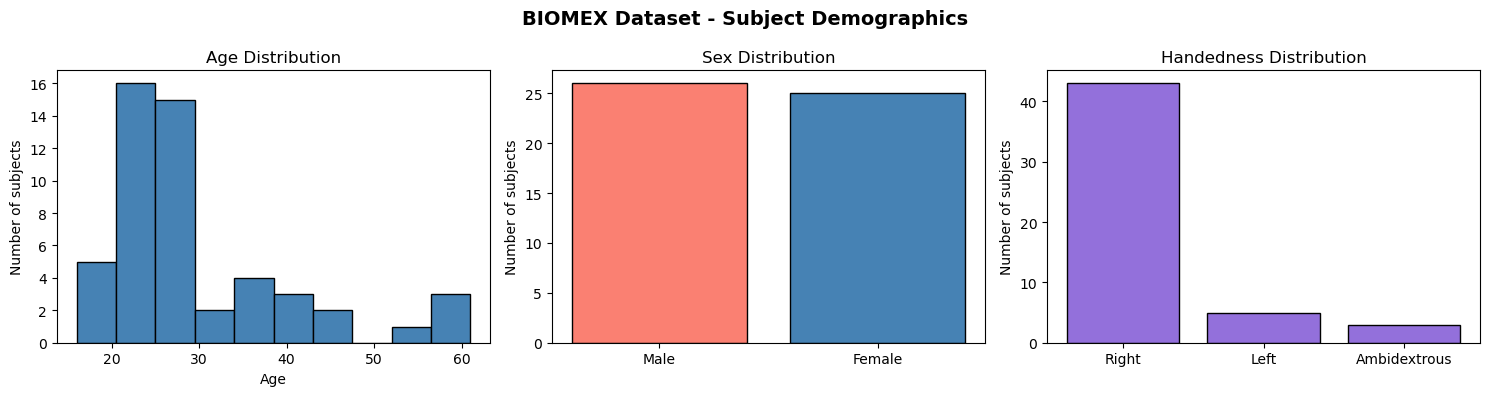


Total subjects: 51


In [ ]:
# ============================================================
# CELL 6: Exploratory visualisation of metadata
# Goal: understand who our subjects are before touching EEG
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# --- Age distribution ---
axes[0].hist(metadata['age'], bins=10, color='steelblue', edgecolor='black')
axes[0].set_title('Age Distribution')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Number of subjects')

# --- Sex distribution ---
sex_counts = metadata['sex'].value_counts()
axes[1].bar(sex_counts.index, sex_counts.values, color=['salmon', 'steelblue'], edgecolor='black')
axes[1].set_title('Sex Distribution')
axes[1].set_ylabel('Number of subjects')

# --- Handedness distribution ---
hand_counts = metadata['handedness'].value_counts()
axes[2].bar(hand_counts.index, hand_counts.values, color='mediumpurple', edgecolor='black')
axes[2].set_title('Handedness Distribution')
axes[2].set_ylabel('Number of subjects')

plt.suptitle('BIOMEX Dataset - Subject Demographics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nTotal subjects: {len(metadata)}")

In [ ]:
# ============================================================
# CELL 7: Explore file structure of one BIOMEX subject (F001)
# ============================================================

subject_path = BIOMEX_ROOT / "F001"

print("=== Files inside F001/ ===")
for item in sorted(subject_path.rglob("*")):  # rglob = recursive
    # Show relative path from subject folder
    print(f"  {'[DIR] ' if item.is_dir() else '[FILE]'} {item.relative_to(subject_path)}")

=== Files inside F001/ ===
  [DIR]  F001
  [DIR]  F001\EEG
  [FILE] F001\EEG\F001-01G04-18.07.18.12.36.17.edf
  [FILE] F001\EEG\F001-01G04.CSV
  [FILE] F001\EEG\F001-01G10-18.07.18.12.29.05.edf
  [FILE] F001\EEG\F001-01G10.CSV
  [DIR]  F001\Video
  [DIR]  F001\Voice
  [FILE] F001\Voice\F001_01G04_1.lab
  [FILE] F001\Voice\F001_01G04_1.wav
  [FILE] F001\Voice\F001_01G04_10.lab
  [FILE] F001\Voice\F001_01G04_10.wav
  [FILE] F001\Voice\F001_01G04_2.lab
  [FILE] F001\Voice\F001_01G04_2.wav
  [FILE] F001\Voice\F001_01G04_3.lab
  [FILE] F001\Voice\F001_01G04_3.wav
  [FILE] F001\Voice\F001_01G04_4.lab
  [FILE] F001\Voice\F001_01G04_4.wav
  [FILE] F001\Voice\F001_01G04_5.lab
  [FILE] F001\Voice\F001_01G04_5.wav
  [FILE] F001\Voice\F001_01G04_6.lab
  [FILE] F001\Voice\F001_01G04_6.wav
  [FILE] F001\Voice\F001_01G04_7.lab
  [FILE] F001\Voice\F001_01G04_7.wav
  [FILE] F001\Voice\F001_01G04_8.lab
  [FILE] F001\Voice\F001_01G04_8.wav
  [FILE] F001\Voice\F001_01G04_9.lab
  [FILE] F001\Voice\F001_01G

- G04 = sesión de secuencias de 4 dígitos
- G10 = sesión de secuencias de 10 dígitos
- Cada sujeto tiene 2 archivos EDF (uno por sesión) + sus CSV equivalentes

In [ ]:
# ============================================================
# CELL 8: Load the first EEG file (F001, G10 session) with MNE
# We use G10 (10-digit sequence) as it's longer = more signal
# We are NOT modifying anything yet, just reading and inspecting
# ============================================================

# Build path to the EDF file
edf_path = BIOMEX_ROOT / "F001" / "F001" / "EEG" / "F001-01G10-18.07.18.12.29.05.edf"

# Load the raw EEG
raw = mne.io.read_raw_edf(edf_path, preload=True)

# ---- Basic info ----
print("=== EEG INFO ===")
print(raw.info)

print(f"\n=== DURATION ===")
print(f"  {raw.times[-1]:.2f} seconds  ({raw.times[-1]/60:.2f} minutes)")

print(f"\n=== SAMPLING RATE ===")
print(f"  {raw.info['sfreq']} Hz")

print(f"\n=== CHANNELS ({len(raw.ch_names)}) ===")
for i, ch in enumerate(raw.ch_names):
    print(f"  [{i:02d}] {ch}")


=== EEG INFO ===
<Info | 8 non-empty values
 bads: []
 ch_names: COUNTER, INTERPOLATED, AF3, F7, F3, FC5, T7, P7, O1, O2, P8, T8, ...
 chs: 36 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 64.0 Hz
 meas_date: 2018-07-18 12:29:06 UTC
 nchan: 36
 projs: []
 sfreq: 128.0 Hz
 subject_info: <subject_info | his_id: F001>
>

=== DURATION ===
  336.99 seconds  (5.62 minutes)

=== SAMPLING RATE ===
  128.0 Hz

=== CHANNELS (36) ===
  [00] COUNTER
  [01] INTERPOLATED
  [02] AF3
  [03] F7
  [04] F3
  [05] FC5
  [06] T7
  [07] P7
  [08] O1
  [09] O2
  [10] P8
  [11] T8
  [12] FC6
  [13] F4
  [14] F8
  [15] AF4
  [16] RAW_CQ
  [17] CQ_AF3
  [18] CQ_F7
  [19] CQ_F3
  [20] CQ_FC5
  [21] CQ_T7
  [22] CQ_P7
  [23] CQ_O1
  [24] CQ_O2
  [25] CQ_P8
  [26] CQ_T8
  [27] CQ_FC6
  [28] CQ_F4
  [29] CQ_F8
  [30] CQ_AF4
  [31] CQ_CMS
  [32] CQ_DRL
  [33] GYROX
  [34] GYROY
  [35] MARKER


In [ ]:
# ============================================================
# CELL 9: Identify which channels are actual EEG
# The Emotiv Epoc has 14 EEG channels (10-20 system)
# The rest are device metadata (counter, gyroscope, markers...)
# ============================================================

# These are the 14 real EEG channels from the Emotiv Epoc
EEG_CHANNELS = ['AF3', 'F7', 'F3', 'FC5', 'T7', 'P7', 'O1',
                 'O2', 'P8', 'T8', 'FC6', 'F8', 'F4', 'AF4']

# These are non-EEG channels (device info, quality, gyro, markers)
non_eeg = [ch for ch in raw.ch_names if ch not in EEG_CHANNELS]

print("=== REAL EEG CHANNELS (14) ===")
for ch in EEG_CHANNELS:
    present = "✓" if ch in raw.ch_names else "✗ MISSING"
    print(f"  {ch}  {present}")

print(f"\n=== NON-EEG CHANNELS ({len(non_eeg)}) — will be dropped ===")
for ch in non_eeg:
    print(f"  {ch}")

# Keep only the 14 EEG channels
raw_eeg = raw.copy().pick(EEG_CHANNELS)

print(f"\n=== After filtering: {len(raw_eeg.ch_names)} channels remaining ===")
print(raw_eeg.ch_names)

=== REAL EEG CHANNELS (14) ===
  AF3  ✓
  F7  ✓
  F3  ✓
  FC5  ✓
  T7  ✓
  P7  ✓
  O1  ✓
  O2  ✓
  P8  ✓
  T8  ✓
  FC6  ✓
  F8  ✓
  F4  ✓
  AF4  ✓

=== NON-EEG CHANNELS (22) — will be dropped ===
  COUNTER
  INTERPOLATED
  RAW_CQ
  CQ_AF3
  CQ_F7
  CQ_F3
  CQ_FC5
  CQ_T7
  CQ_P7
  CQ_O1
  CQ_O2
  CQ_P8
  CQ_T8
  CQ_FC6
  CQ_F4
  CQ_F8
  CQ_AF4
  CQ_CMS
  CQ_DRL
  GYROX
  GYROY
  MARKER

=== After filtering: 14 channels remaining ===
['AF3', 'F7', 'F3', 'FC5', 'T7', 'P7', 'O1', 'O2', 'P8', 'T8', 'FC6', 'F8', 'F4', 'AF4']


C:\Users\Laura\AppData\Local\Temp\ipykernel_28152\1180487488.py:34: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


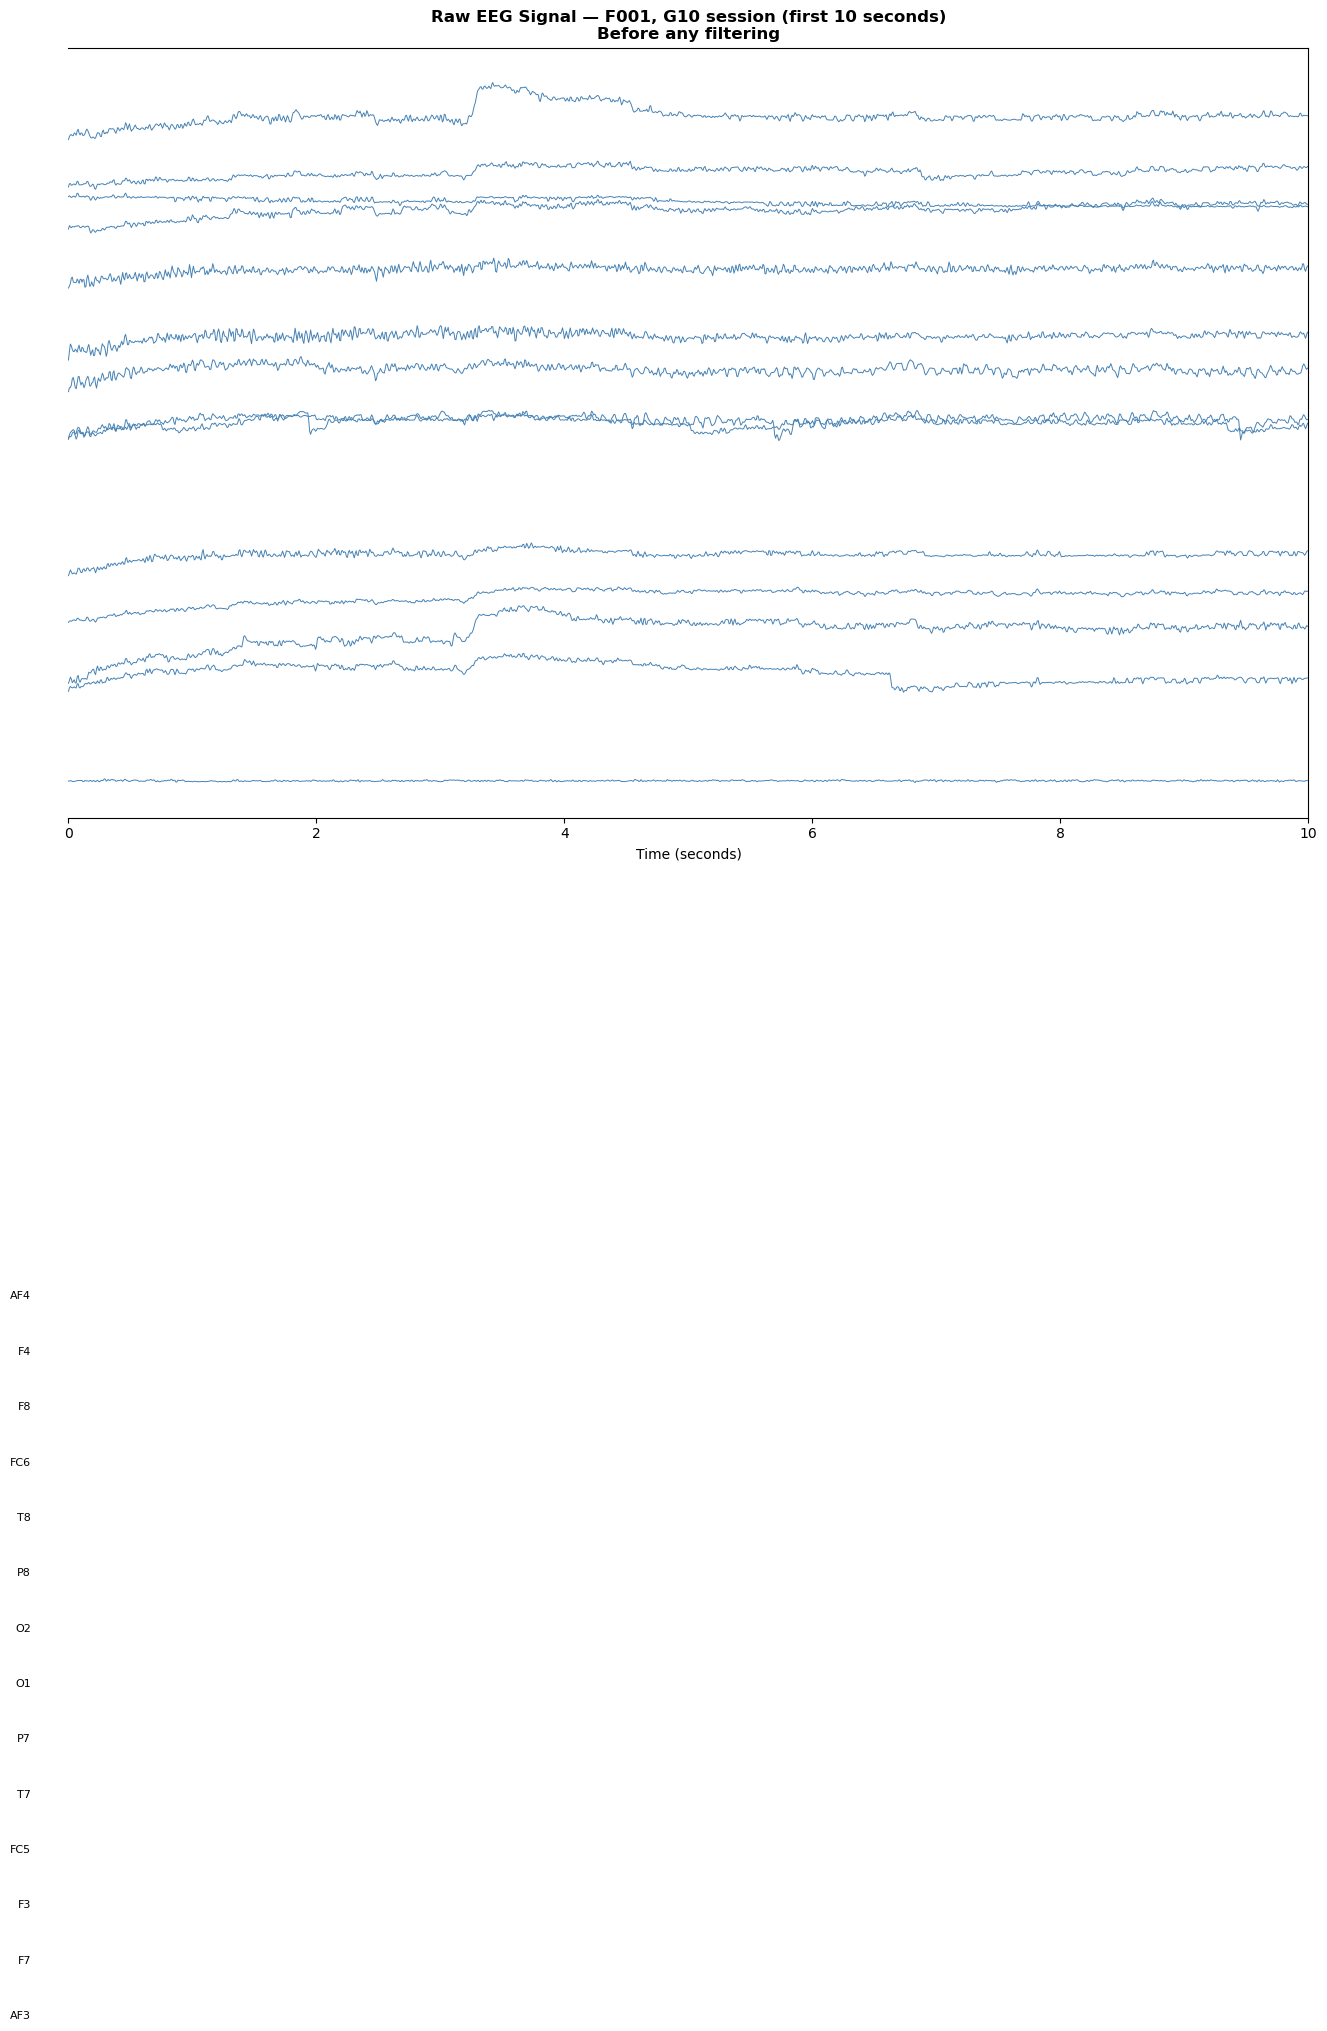

=== RAW SIGNAL STATISTICS (microvolts) ===
  AF3    mean=4464.69  std=  2.65  min= 4449.23  max= 4481.03
  F7     mean=4792.08  std= 79.42  min= 3910.77  max= 7919.49
  F3     mean=4725.99  std= 22.26  min= 4451.79  max= 4796.41
  FC5    mean=4244.42  std= 22.94  min= 4116.41  max= 4345.64
  T7     mean=4463.66  std= 17.88  min= 4272.31  max= 4612.82
  P7     mean=4743.14  std= 20.67  min= 4519.49  max= 4867.18
  O1     mean=4752.46  std= 23.46  min= 4492.82  max= 4918.97
  O2     mean=4361.17  std= 22.22  min= 4178.97  max= 4466.15
  P8     mean=4696.93  std= 19.93  min= 4531.79  max= 4786.15
  T8     mean=4266.17  std= 19.00  min= 4074.36  max= 4382.56
  FC6    mean=4533.15  std= 21.35  min= 4314.87  max= 4696.92
  F8     mean=4341.25  std= 29.89  min= 4181.54  max= 4572.82
  F4     mean=4272.72  std= 17.97  min= 4124.10  max= 4353.85
  AF4    mean=4259.09  std= 26.15  min= 4103.59  max= 4402.05


In [ ]:
# ============================================================
# CELL 10: Visualise the raw EEG signal (first 10 seconds)
# Goal: see what the signal looks like BEFORE any filtering
# We plot all 14 channels stacked vertically
# ============================================================

# Extract data as numpy array: shape = (14 channels, n_samples)
data, times = raw_eeg[:, :]

# We'll plot only the first 10 seconds to keep it readable
sfreq    = int(raw_eeg.info['sfreq'])   # 128 Hz
n_show   = 10 * sfreq                   # 10 seconds = 1280 samples

fig, ax = plt.subplots(figsize=(16, 10))

# Plot each channel with a vertical offset so they don't overlap
offset      = 200   # microvolts separation between channels
ch_names    = raw_eeg.ch_names

for i, ch in enumerate(ch_names):
    signal = data[i, :n_show] * 1e6     # convert Volts → microvolts
    ax.plot(times[:n_show], signal + i * offset,
            linewidth=0.7, color='steelblue')
    ax.text(-0.3, i * offset, ch,
            ha='right', va='center', fontsize=8)

ax.set_xlabel("Time (seconds)")
ax.set_title("Raw EEG Signal — F001, G10 session (first 10 seconds)\nBefore any filtering", 
             fontsize=12, fontweight='bold')
ax.set_yticks([])          # hide y-axis numbers, offsets are artificial
ax.set_xlim(0, 10)
ax.spines['left'].set_visible(False)

plt.tight_layout()
plt.show()

# Also print basic signal statistics
print("=== RAW SIGNAL STATISTICS (microvolts) ===")
for i, ch in enumerate(ch_names):
    sig = data[i, :] * 1e6
    print(f"  {ch:5s}  mean={sig.mean():7.2f}  std={sig.std():6.2f}  "
          f"min={sig.min():8.2f}  max={sig.max():8.2f}")

- Offset DC de ~4500 µV
- F7 tiene std=79 µV cuando todos los demás tienen std ~20 µV

=== DC OFFSET per channel (mean value) ===
  AF3    4464.7 µV
  F7     4792.1 µV
  F3     4726.0 µV
  FC5    4244.4 µV
  T7     4463.7 µV
  P7     4743.1 µV
  O1     4752.5 µV
  O2     4361.2 µV
  P8     4696.9 µV
  T8     4266.2 µV
  FC6    4533.1 µV
  F8     4341.3 µV
  F4     4272.7 µV
  AF4    4259.1 µV


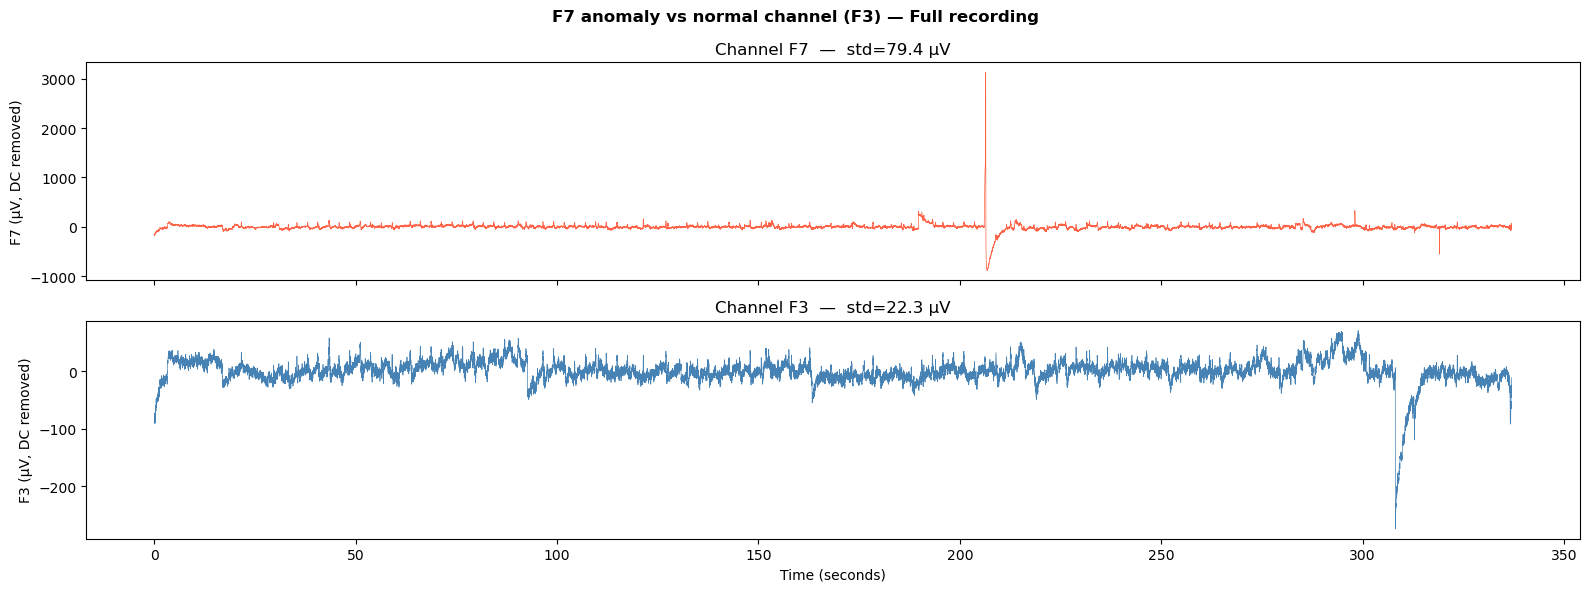


=== F7 outlier samples (> 3 std from mean) ===
  445 / 43136 samples  (1.0%)


In [ ]:
# ============================================================
# CELL 11: Investigate the DC offset and the F7 anomaly
# ============================================================

# --- 1. DC offset: all means are ~4500 µV instead of ~0 ---
# This is normal for Emotiv Epoc — it adds a hardware offset
# We confirm it's consistent across channels

print("=== DC OFFSET per channel (mean value) ===")
for i, ch in enumerate(ch_names):
    mean_uv = data[i, :].mean() * 1e6
    print(f"  {ch:5s}  {mean_uv:.1f} µV")

# --- 2. F7 anomaly: std=79 vs ~20 for all others ---
# Let's plot F7 vs a normal channel (F3) for the full recording
fig, axes = plt.subplots(2, 1, figsize=(16, 6), sharex=True)

for ax, ch, color in zip(axes, ['F7', 'F3'], ['tomato', 'steelblue']):
    idx = ch_names.index(ch)
    sig = data[idx, :] * 1e6
    sig_centered = sig - sig.mean()   # remove DC offset to see oscillations
    ax.plot(times, sig_centered, linewidth=0.5, color=color)
    ax.set_ylabel(f"{ch} (µV, DC removed)")
    ax.set_title(f"Channel {ch}  —  std={sig.std():.1f} µV")

axes[-1].set_xlabel("Time (seconds)")
plt.suptitle("F7 anomaly vs normal channel (F3) — Full recording", 
             fontweight='bold')
plt.tight_layout()
plt.show()

# --- 3. How many samples in F7 exceed 3 std from its mean? ---
idx_f7 = ch_names.index('F7')
sig_f7 = data[idx_f7, :] * 1e6
threshold = sig_f7.mean() + 3 * sig_f7.std()
n_outliers = (np.abs(sig_f7 - sig_f7.mean()) > 3 * sig_f7.std()).sum()
total = len(sig_f7)
print(f"\n=== F7 outlier samples (> 3 std from mean) ===")
print(f"  {n_outliers} / {total} samples  ({100*n_outliers/total:.1f}%)")


- F7 — tiene picos brutales (~3000 µV y ~-1000 µV) en momentos puntuales. Son artefactos de movimiento o mal contacto del electrodo momentáneo. Solo afectan al 1% de las muestras, así que la señal en sí no está perdida.
- F3 — tiene al final (~300s), una deriva lenta hacia -300 µV. Eso es típico de cuando el sujeto se mueve o el electrodo pierde contacto al final de la sesión.

El offset DC de ~4500 µV es consistente en todos los canales (hardware del Emotiv)

✓ Step 1: Average reference applied (DC offset removed)
✓ Step 2: Bandpass filter 1–50 Hz applied
✓ Step 3: Notch filter at 50 Hz applied


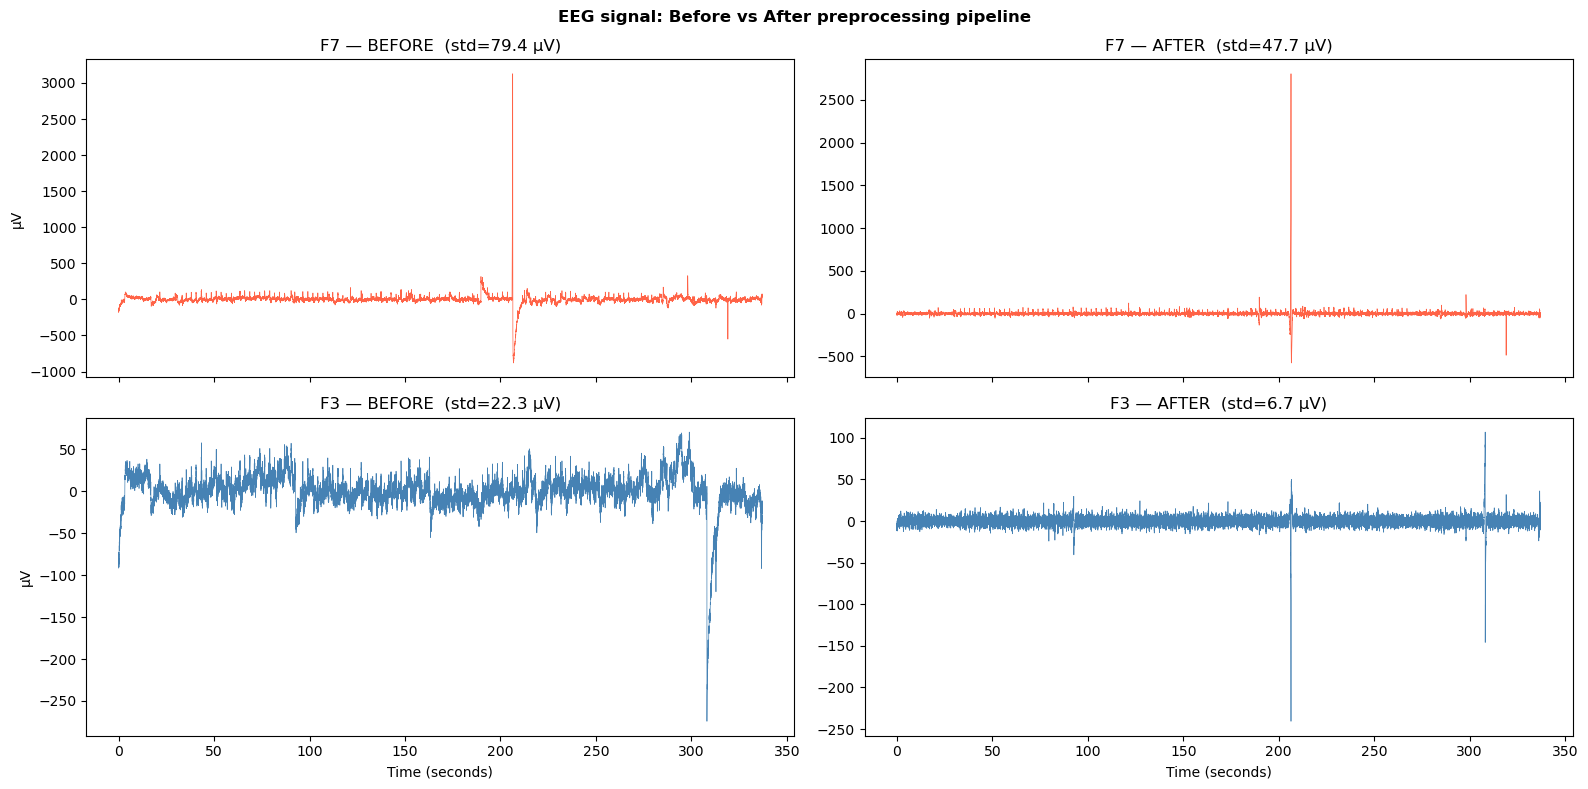


=== STD comparison before vs after (µV) ===
Channel    Before     After
----------------------------
AF3         2.65      9.04
F7         79.42     47.71
F3         22.26      6.65
FC5        22.94      7.81
T7         17.88      7.05
P7         20.67      8.65
O1         23.46     10.71
O2         22.22     13.23
P8         19.93     10.85
T8         19.00      9.06
FC6        21.35      8.84
F8         29.89     10.02
F4         17.97      6.24
AF4        26.15     13.85


In [ ]:
# ============================================================
# CELL 12: Preprocessing pipeline
# Steps (in order):
#   1. Remove DC offset (re-reference to average)
#   2. Bandpass filter: 1–50 Hz
#      - High-pass 1 Hz: removes slow drifts like the one in F3
#      - Low-pass 50 Hz: removes 50 Hz powerline noise + high freq
#   3. Notch filter at 50 Hz: extra removal of powerline noise
# We do NOT remove F7 spikes yet — that comes after (ICA or clipping)
# ============================================================

raw_filtered = raw_eeg.copy()

# --- Step 1: Average reference (removes DC offset) ---
# Each sample becomes: value - mean(all channels at that moment)
raw_filtered.set_eeg_reference('average', projection=False, verbose=False)
print("✓ Step 1: Average reference applied (DC offset removed)")

# --- Step 2: Bandpass filter 1–50 Hz ---
raw_filtered.filter(
    l_freq=1.0,    # high-pass: remove slow drifts (< 1 Hz)
    h_freq=50.0,   # low-pass:  remove powerline + high freq noise
    fir_window='hamming',
    verbose=False
)
print("✓ Step 2: Bandpass filter 1–50 Hz applied")

# --- Step 3: Notch filter at 50 Hz (Spain powerline frequency) ---
raw_filtered.notch_filter(freqs=50.0, verbose=False)
print("✓ Step 3: Notch filter at 50 Hz applied")

# --- Compare before vs after for F3 and F7 ---
data_filt, _ = raw_filtered[:, :]

fig, axes = plt.subplots(2, 2, figsize=(16, 8), sharex=True)

for row, ch in enumerate(['F7', 'F3']):
    idx = ch_names.index(ch)
    
    # Before
    sig_raw = data[idx, :] * 1e6
    sig_raw -= sig_raw.mean()
    axes[row, 0].plot(times, sig_raw, linewidth=0.5, 
                      color='tomato' if ch == 'F7' else 'steelblue')
    axes[row, 0].set_title(f"{ch} — BEFORE  (std={sig_raw.std():.1f} µV)")
    axes[row, 0].set_ylabel("µV")

    # After
    sig_filt = data_filt[idx, :] * 1e6
    axes[row, 1].plot(times, sig_filt, linewidth=0.5,
                      color='tomato' if ch == 'F7' else 'steelblue')
    axes[row, 1].set_title(f"{ch} — AFTER  (std={sig_filt.std():.1f} µV)")

for ax in axes[-1]:
    ax.set_xlabel("Time (seconds)")

plt.suptitle("EEG signal: Before vs After preprocessing pipeline", 
             fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

print("\n=== STD comparison before vs after (µV) ===")
print(f"{'Channel':6s}  {'Before':>8s}  {'After':>8s}")
print("-" * 28)
for i, ch in enumerate(ch_names):
    before = data[i, :].std() * 1e6
    after  = data_filt[i, :].std() * 1e6
    print(f"{ch:6s}  {before:8.2f}  {after:8.2f}")

- La mayoría de canales están ahora en el rango 6-14 µV — normal para EEG

- F7 sigue con std=47 µV — el pico de 2500 µV sigue ahí, el filtro no lo elimina porque es un artefacto de amplitud, no de frecuencia

- AF3 subió de 2.65 → 9 µV — esto es raro, antes estaba "demasiado quieto" (posible electrodo sin contacto), ahora tras referenciar parece más normal

=== Samples exceeding ±150 µV threshold ===
Channel   N samples   % total
--------------------------------
AF3              7      0.02%
F7             185      0.43%
F3               7      0.02%
FC5              7      0.02%
T7               0      0.00%
P7               0      0.00%
O1               7      0.02%
O2               7      0.02%
P8               7      0.02%
T8               7      0.02%
FC6              8      0.02%
F8               7      0.02%
F4               7      0.02%
AF4              7      0.02%


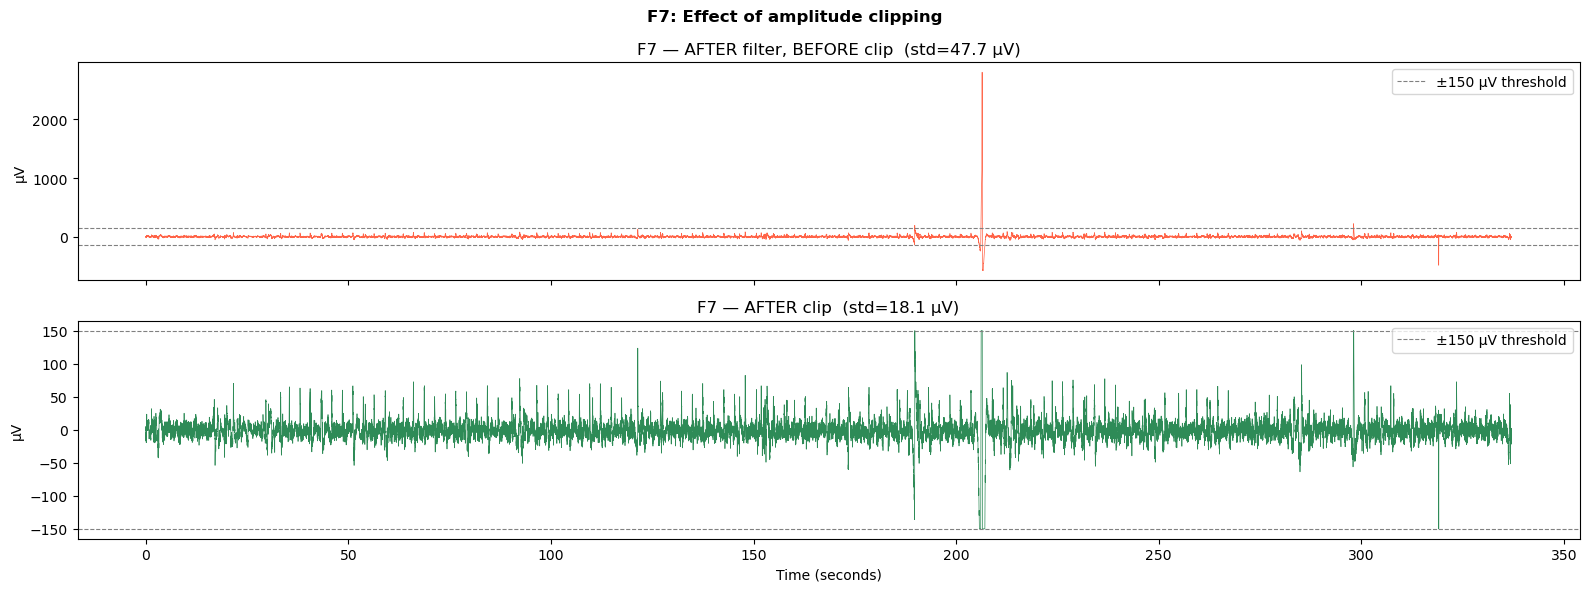


=== Final STD after clipping (µV) ===
  AF3    8.79 µV
  F7     18.14 µV
  F3     6.31 µV
  FC5    7.57 µV
  T7     7.05 µV
  P7     8.65 µV
  O1     10.51 µV
  O2     13.08 µV
  P8     10.61 µV
  T8     8.81 µV
  FC6    8.60 µV
  F8     9.84 µV
  F4     5.87 µV
  AF4    13.71 µV


In [ ]:
# ============================================================
# CELL 13: Amplitude-based artifact rejection
# Problem: F7 has spikes of ~2500 µV — way above normal EEG
# Solution: clip any sample exceeding ±150 µV to ±150 µV
# 150 µV is a standard threshold for EEG artifact rejection
# This is conservative — we preserve the signal shape 
# and only limit extreme outliers
# ============================================================

raw_clean = raw_filtered.copy()
data_clean, _ = raw_clean[:, :]

# Define threshold
THRESHOLD_UV = 150e-6   # 150 µV in Volts (MNE works in Volts)

# Count how many samples will be clipped per channel
print("=== Samples exceeding ±150 µV threshold ===")
print(f"{'Channel':6s}  {'N samples':>10s}  {'% total':>8s}")
print("-" * 32)
for i, ch in enumerate(ch_names):
    n_exceed = (np.abs(data_clean[i, :]) > THRESHOLD_UV).sum()
    pct = 100 * n_exceed / data_clean.shape[1]
    flag = "  ← HIGH" if pct > 1 else ""
    print(f"{ch:6s}  {n_exceed:10d}  {pct:8.2f}%{flag}")

# Apply clipping
data_clean = np.clip(data_clean, -THRESHOLD_UV, THRESHOLD_UV)
raw_clean._data = data_clean

# --- Verify F7 after clipping ---
fig, axes = plt.subplots(2, 1, figsize=(16, 6), sharex=True)

for ax, (d, label, color) in zip(axes, [
    (data_filt, "AFTER filter, BEFORE clip", "tomato"),
    (data_clean, "AFTER clip",               "seagreen")
]):
    idx = ch_names.index('F7')
    ax.plot(times, d[idx, :] * 1e6, linewidth=0.5, color=color)
    ax.set_title(f"F7 — {label}  (std={d[idx,:].std()*1e6:.1f} µV)")
    ax.set_ylabel("µV")
    ax.axhline( 150, color='gray', linestyle='--', linewidth=0.8, label='±150 µV threshold')
    ax.axhline(-150, color='gray', linestyle='--', linewidth=0.8)
    ax.legend(loc='upper right')

axes[-1].set_xlabel("Time (seconds)")
plt.suptitle("F7: Effect of amplitude clipping", fontweight='bold')
plt.tight_layout()
plt.show()

print("\n=== Final STD after clipping (µV) ===")
for i, ch in enumerate(ch_names):
    print(f"  {ch:5s}  {data_clean[i,:].std()*1e6:.2f} µV")

- F7 bajó de 79 → 18 µV — los picos extremos eliminados, señal ahora comparable al resto

- Todos los canales entre 6-18 µV — rango fisiológicamente correcto para EEG

- Los 7 samples que superan el umbral en casi todos los canales simultáneamente son probablemente el mismo artefacto global (movimiento de cabeza) — normal

In [6]:
# ============================================================
# CELL 14: Wrap the full preprocessing pipeline into a function
# This function will be reused for ALL subjects
# Input:  path to an EDF file
# Output: clean numpy array (14 channels x n_samples) + metadata
# ============================================================

def preprocess_eeg(edf_path, threshold_uv=150):
    """
    Full preprocessing pipeline for one BIOMEX EDF file.
    
    Steps:
        1. Load EDF and keep only the 14 EEG channels
        2. Average reference (removes DC offset)
        3. Bandpass filter 1-50 Hz (removes drifts + high freq noise)
        4. Notch filter at 50 Hz (removes Spanish powerline noise)
        5. Amplitude clipping at ±threshold_uv µV
    
    Parameters
    ----------
    edf_path    : Path or str — path to the .edf file
    threshold_uv: float — clipping threshold in microvolts (default 150)
    
    Returns
    -------
    data_clean  : np.ndarray, shape (14, n_samples), in Volts
    ch_names    : list of 14 channel names
    sfreq       : float — sampling frequency (128 Hz)
    times       : np.ndarray — time axis in seconds
    """
    
    EEG_CHANNELS = ['AF3', 'F7', 'F3', 'FC5', 'T7', 'P7', 'O1',
                    'O2', 'P8', 'T8', 'FC6', 'F8', 'F4', 'AF4']
    
    # 1. Load and pick EEG channels only
    raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)
    raw.pick(EEG_CHANNELS)
    
    # 2. Average reference
    raw.set_eeg_reference('average', projection=False, verbose=False)
    
    # 3. Bandpass 1-50 Hz
    raw.filter(l_freq=1.0, h_freq=50.0, fir_window='hamming', verbose=False)
    
    # 4. Notch at 50 Hz
    raw.notch_filter(freqs=50.0, verbose=False)
    
    # 5. Amplitude clipping
    data, times = raw[:, :]
    threshold_v = threshold_uv * 1e-6      # convert µV → V
    data = np.clip(data, -threshold_v, threshold_v)
    
    return data, raw.ch_names, raw.info['sfreq'], times


# ---- Quick test on F001 to verify the function works ----
edf_path_test = BIOMEX_ROOT / "F001" / "F001" / "EEG" / "F001-01G10-18.07.18.12.29.05.edf"
data_test, chs, sfreq, times = preprocess_eeg(edf_path_test)

print("=== preprocess_eeg() test on F001 ===")
print(f"  Output shape : {data_test.shape}  (channels x samples)")
print(f"  Channels     : {chs}")
print(f"  Sampling rate: {sfreq} Hz")
print(f"  Duration     : {times[-1]:.1f} seconds")
print(f"  Value range  : [{data_test.min()*1e6:.1f}, {data_test.max()*1e6:.1f}] µV")

=== preprocess_eeg() test on F001 ===
  Output shape : (14, 43136)  (channels x samples)
  Channels     : ['AF3', 'F7', 'F3', 'FC5', 'T7', 'P7', 'O1', 'O2', 'P8', 'T8', 'FC6', 'F8', 'F4', 'AF4']
  Sampling rate: 128.0 Hz
  Duration     : 337.0 seconds
  Value range  : [-150.0, 150.0] µV


In [ ]:
# ============================================================
# CELL 15: Power Spectral Density (PSD) feature extraction
# For each channel we compute the average power in each band
# Result: 14 channels x 5 bands = 70 features per subject
# ============================================================

from scipy.signal import welch

# Define frequency bands
BANDS = {
    'delta': (1, 4),
    'theta': (4, 8),
    'alpha': (8, 13),
    'beta':  (13, 30),
    'gamma': (30, 50),
}

def compute_psd_features(data, sfreq, bands=BANDS):
    """
    Compute mean band power for each channel using Welch's method.
    
    Parameters
    ----------
    data   : np.ndarray, shape (n_channels, n_samples), in Volts
    sfreq  : float — sampling frequency
    bands  : dict — {band_name: (f_low, f_high)}
    
    Returns
    -------
    features    : np.ndarray, shape (n_channels * n_bands,)
    feature_names: list of strings e.g. ['AF3_delta', 'AF3_theta', ...]
    """
    
    n_channels = data.shape[0]
    features = []
    feature_names = []
    
    for ch_idx, ch_name in enumerate(EEG_CHANNELS):
        # Welch method: estimates PSD by averaging periodograms
        # nperseg=256 = 2 seconds of signal at 128 Hz
        freqs, psd = welch(data[ch_idx, :], fs=sfreq, nperseg=256)
        
        for band_name, (f_low, f_high) in bands.items():
            # Find frequency indices within this band
            band_mask = (freqs >= f_low) & (freqs < f_high)
            
            # Mean power in this band (in µV²/Hz)
            band_power = psd[band_mask].mean() * 1e12  # V²/Hz → µV²/Hz
            
            features.append(band_power)
            feature_names.append(f"{ch_name}_{band_name}")
    
    return np.array(features), feature_names


# --- Test on F001 ---
features_test, feature_names = compute_psd_features(data_test, sfreq)

print(f"=== PSD Features for F001 ===")
print(f"  Feature vector length: {len(features_test)}")
print(f"  (14 channels × 5 bands = {14*5})")
print(f"\n  First 10 features:")
for name, val in zip(feature_names[:10], features_test[:10]):
    print(f"    {name:15s}  {val:.4f} µV²/Hz")

=== PSD Features for F001 ===
  Feature vector length: 70
  (14 channels × 5 bands = 70)

  First 10 features:
    AF3_delta        13.4412 µV²/Hz
    AF3_theta        1.7231 µV²/Hz
    AF3_alpha        0.7470 µV²/Hz
    AF3_beta         0.3549 µV²/Hz
    AF3_gamma        0.1804 µV²/Hz
    F7_delta         63.1752 µV²/Hz
    F7_theta         5.7608 µV²/Hz
    F7_alpha         1.6518 µV²/Hz
    F7_beta          0.9092 µV²/Hz
    F7_gamma         0.4553 µV²/Hz
